# Storytelling with Data – Potęga Tekstu i Agregacji

---

Witaj na kolejnych zajęciach! Dzisiaj kontynuujemy naszą naukę na podstawie zasad z książki **"Storytelling with Data"** Cole Nussbaumer Knaflic.

Podczas tych zajęć nauczymy się m.in.:
- **Potęgi tekstu (Simple Text):** Cole uczy nas, że kiedy mamy do przekazania zaledwie jedną lub kilka kluczowych liczb, tworzenie pełnoprawnego wykresu (z osiami, siatką i legendą) przynosi więcej szkody niż pożytku. Czasami **najlepszy wykres to brak wykresu**!
- **Interpolacji liniowej:** Zamiast usuwać brakujące dane w szeregach czasowych, nauczymy się "zgadywać" ich wartość na podstawie lat sąsiednich.
- **Agregacji:** Zobaczymy, jak wyciągać potężne, wysokopoziomowe wnioski z surowych danych.

---

### Zadanie 0: Logowanie do systemu

Każdy z Was otrzymuje poniżej swój indywidualny kod dostępu. Aby go aktywować, postępujcie zgodnie z poniższymi krokami:

1. Zaloguj się na swoje istniejące konto na stronie [https://www.tableau.com/](https://www.tableau.com/) lub załóż nowe konto, używając swojego uczelnianego adresu e-mail.
2. Wejdź na stronę: [http://elearning.tableau.com](http://elearning.tableau.com).
3. Zarejestruj się w Tableau Learning Center, podając swój indywidualny kod dostępu.
   *(Uwaga dla powracających użytkowników: Jeśli korzystaliście już wcześniej z eLearningu, spróbujcie po prostu się zalogować zamiast zakładać nowe konto. Po zalogowaniu system powinien poprosić Was o podanie nowego kodu.)*
4. Twój indywidualny kod dostępu do platformy to znajdziesz w [tej tabeli](https://docs.google.com/spreadsheets/d/1QlqkNCofPMxBMxhQCV0mPeHRQ6GnUmgyfi0ojgtX4SQ/edit?gid=0#gid=0) (do każdego indeksu jest przypisany kod dostępu).
5. Po poprawnym zalogowaniu się zmień kolor swojego wiersza na zielony.

---

## 1. Wczytywanie, łączenie i mądre czyszczenie danych

---

Tym razem oprócz wskaźnika szczęścia pobierzemy znacznie więcej danych dotyczących **Jakości Życia (Quality of Life)**. Zobaczymy, czy poszczególne indeksy, takie jak siła nabywcza, bezpieczeństwo, koszty życia, jakość opieki zdrowotnej czy zanieczyszczenie środowiska, pokrywają się z poczuciem szczęścia w różnych regionach świata.

| Wskaźnik (Kolumna) | Nazwa polska | Kierunek | Opis |
| :--- | :--- | :--- | :--- |
| `life evaluation` | Wskaźnik Szczęścia | ⬆️ Wyższa to lepsza | Średnia ocena deklarowanego zadowolenia z życia (skala 0-10). |
| `quality_of_life_index` | Ogólna Jakość Życia | ⬆️ Wyższa to lepsza | Szacunkowa ogólna jakość życia wynikająca z empirycznej formuły uwzględniającej pozostałe wskaźniki. |
| `purchasing_power_index` | Siła Nabywcza | ⬆️ Wyższa to lepsza | Określa relatywną zdolność nabywczą dóbr i usług przez mieszkańców. |
| `safety_index` | Bezpieczeństwo | ⬆️ Wyższa to lepsza | Ocena ogólnego poziomu bezpieczeństwa w danym regionie. |
| `health_care_index` | Opieka Zdrowotna | ⬆️ Wyższa to lepsza | Szacunkowa jakość systemu opieki zdrowotnej, personelu medycznego i infrastruktury. |
| `climate_index` | Klimat | ⬆️ Wyższa to lepsza | Ocena ogólnej przyjazności klimatu w danym regionie. |
| `cost_of_living_index` | Koszty Życia | ⬇️ Niższa to lepsza | Relatywne koszty dóbr konsumpcyjnych (np. jedzenie, transport) z wyłączeniem czynszu. |
| `property_price_to_income_ratio`| Ceny Nieruchomości / Dochód | ⬇️ Niższa to lepsza | Podstawowa miara przystępności zakupu mieszkań (niższy wskaźnik oznacza łatwiejszy zakup w stosunku do zarobków). |
| `traffic_commute_time_index` | Czas Dojazdów | ⬇️ Niższa to lepsza | Średni czas spędzany przez mieszkańców w korkach i podczas dojazdów do pracy. |
| `pollution_index` | Zanieczyszczenie | ⬇️ Niższa to lepsza | Szacunkowa ocena ogólnego zanieczyszczenia środowiska (powietrza, wody itp.). |

---

**Instrukcja krok po kroku:**

1. Importuj biblioteki: `pandas as pd`, `seaborn as sns`, `matplotlib.pyplot as plt`. Ustaw styl wykresów biblioteki seaborn za pomocą funkcji `sns.set_theme(style="white")`.
2. Wczytaj trzy pliki z GitHuba (używając linków "Raw" z domeną `raw.githubusercontent.com` wewnątrz funkcji `pd.read_csv()`): `happiness_index.csv`, `world_data.csv` oraz `quality_of_life_index.csv`.
3. Standaryzacja nazw: W tabeli Quality of Life kolumna z rokiem nazywa się `Year`. Użyj metody `.rename(columns={'Year': 'year'}, inplace=True)`, aby ujednolicić nazwy.
4. Filtrowanie kolumn (najlepsza praktyka przed łączeniem!):
   * Z tabeli ze szczęściem zostaw tylko: `['country', 'year', 'life evaluation']`.
   * Z tabeli ze światem zostaw: `['country', 'Region']`.
   * Z tabeli z jakością życia zostaw szeroki wachlarz wskaźników: `['country', 'year', 'quality_of_life_index', 'purchasing_power_index', 'safety_index', 'health_care_index', 'cost_of_living_index', 'property_price_to_income_ratio', 'traffic_commute_time_index', 'pollution_index', 'climate_index']`.
5. Połącz tabele używając funkcji `pd.merge()`. Najpierw połącz szczęście z jakością życia po listach kolumn `on=['country', 'year']` (użyj argumentu `how='inner'`). Wynik nadpisz do zmiennej `df`. Następnie połącz `df` z tabelą o świecie używając `on='country'` oraz argumentu `how='inner'`.
6. **Filtrowanie lat:** Będziemy analizować tylko najnowsze trendy z lat 2016-2024. Odfiltruj z ramki `df` wiersze, dla których rok jest większy lub równy 2016. Użyj `df = df[df['year'] >= 2016]`.
7. Sortowanie i konwersja typów: Zadbaj o prawidłowe posortowanie danych używając `df = df.sort_values(by=['country', 'year'])`. Stwórz listę wszystkich 10 kolumn numerycznych: `kolumny_num =['life evaluation', 'quality_of_life_index', 'purchasing_power_index', 'safety_index', 'health_care_index', 'cost_of_living_index', 'property_price_to_income_ratio', 'traffic_commute_time_index', 'pollution_index', 'climate_index']`. Wymuś ich konwersję na wartości liczbowe metodą `df[kolumny_num] = df[kolumny_num].apply(pd.to_numeric, errors='coerce')` (zapobiega to problemom przy późniejszej agregacji).
8. Interpolacja braków danych (Magia Pandas): Aby nie tracić państw, dla których brakuje pojedynczych lat, użyjemy interpolacji liniowej. Wykorzystaj zaawansowaną transformację w grupach, dodając `infer_objects(copy=False)` aby wyeliminować komunikaty ostrzegawcze (FutureWarning): `df[kolumny_num] = df.groupby('country')[kolumny_num].transform(lambda x: x.infer_objects(copy=False).interpolate(method='linear', limit_direction='both'))`. Na koniec usuń resztki (kraje bez wystarczających danych) za pomocą `df.dropna(inplace=True)`.
9. Agregacja: Stwórz nową ramkę `df_region`. Zgrupuj dane po kolumnie Region (`df.groupby('Region')`) i wylicz medianę dla poszczególnych regionów przekazując argument `numeric_only=True` do metody `.median()`. Na końcu zresetuj indeks (`.reset_index()`). Wyświetl gotową ramkę wywołując `display(df_region)`.

---

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white")

url_happiness = "https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/refs/heads/main/data/happiness_index.csv"
url_world = "https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/refs/heads/main/data/world_data.csv"
url_quality = "https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/refs/heads/main/data/quality_of_life_index.csv"

happiness_df = pd.read_csv(url_happiness)
world_df = pd.read_csv(url_world)
quality_of_life_df = pd.read_csv(url_quality)
quality_of_life_df.rename(columns={'Year': 'year'}, inplace=True)

happiness_df = happiness_df[['country', 'year', 'life evaluation']]
world_df = world_df[['country', 'Region']]
quality_of_life_df = quality_of_life_df[['country', 'year', 'quality_of_life_index', 'purchasing_power_index', 'safety_index', 'health_care_index', 'cost_of_living_index', 'property_price_to_income_ratio', 'traffic_commute_time_index', 'pollution_index', 'climate_index']]

df = pd.merge(happiness_df, quality_of_life_df, on=['country', 'year'], how='inner')
df = pd.merge(df, world_df, on='country', how='inner')
df = df[df['year'] >= 2016]

df = df.sort_values(by=['country', 'year'])
kolumny_num =['life evaluation', 'quality_of_life_index', 'purchasing_power_index', 'safety_index', 'health_care_index', 'cost_of_living_index', 'property_price_to_income_ratio', 'traffic_commute_time_index', 'pollution_index', 'climate_index']
df[kolumny_num] = df[kolumny_num].apply(pd.to_numeric, errors='coerce')

df[kolumny_num] = df.groupby('country')[kolumny_num].transform(lambda x: x.infer_objects(copy=False).interpolate(method='linear', limit_direction='both'))
df.dropna(inplace=True)

df_region = df.groupby('Region').median(numeric_only=True).reset_index()
display(df_region)

,Region,year,life evaluation,quality_of_life_index,purchasing_power_index,safety_index,health_care_index,cost_of_living_index,property_price_to_income_ratio,traffic_commute_time_index,pollution_index,climate_index
0,AFRICA,2021.0,4.7230,96.95,30.50,43.25,48.80,31.7,12.85,48.15,70.70,92.00
1,ASIA,2020.0,5.4510,99.05,38.60,56.05,67.10,36.0,16.90,43.05,73.15,64.95
2,EUROPE & NORTHERN AMERICA,2020.0,6.4765,163.65,75.45,65.65,68.95,59.5,9.80,30.60,33.80,78.10
3,LATIN AMERICA,2021.0,6.2930,114.30,36.40,44.20,66.30,38.7,16.10,40.60,61.20,94.20
4,NEAR EAST,2021.0,6.3905,148.35,86.95,68.30,64.35,58.0,7.45,36.30,62.50,85.15
5,OCEANIA,2020.0,7.2115,182.70,100.20,57.55,73.65,76.5,8.10,34.70,23.70,93.80


## 2. Make-over: Galeria Simple Text z naciskiem na regiony

---

*(Inspiracja: SWD, Rozdział 2 "Choosing an effective visual" oraz Rozdział 4 "Focus your audience's attention")*

Cole Nussbaumer Knaflic w swojej książce zauważa, że kiedy mamy do przekazania tylko jedną lub dwie kluczowe liczby, zamykanie ich w tradycyjnym wykresie (np. słupkowym) mija się z celem. Oś, siatka i legendy wprowadzają niepotrzebny szum poznawczy. Włożenie zaledwie kilku punktów danych na wykres sprawia, że liczby tracą swoją siłę przebicia (jak pisze autorka: *"lose some of their oomph"*). Zamiast zmuszać odbiorcę do odczytywania wartości z osi y, Cole zaleca użycie metody **Simple Text**: wyświetlenie samej liczby - maksymalnie wyeksponowanej - wraz z kilkoma słowami pomocniczymi.

W naszej zagregowanej tabeli `df_region` mamy aż 10 wspaniałych wskaźników. Aby pokazać kontrasty na świecie, zrobimy zestawienie najlepszych (top) i najgorszych (bottom) regionów w poszczególnych kategoriach. Mając 10 parzystych metryk, użyjemy obszernej siatki pod-wykresów: **4 wiersze i 5 kolumn**. Wiersz pierwszy i trzeci pokaże zwycięzców danych kategorii, a wiersz drugi i czwarty – przegranych.

Dodatkowo, wykorzystamy atrybuty przeduwagowe (preattentive attributes) ze strategią opisaną w rozdziale 4. Zamiast używać przypadkowych kolorów, **przypiszemy unikalny kolor każdemu regionowi**. Dzięki temu, gdy spojrzysz na ogromną galerię liczb, Twój mózg natychmiast powiąże ten sam kolor i dostrzeże wzorce (np. z łatwością zauważysz, w jak wielu kategoriach dominuje jeden określony kolor/region).

---

**Instrukcja krok po kroku:**

1. Zbuduj siatkę 4x5 pod-wykresów (subplotów) używając `fig, axes = plt.subplots(4, 5, figsize=(26, 16))`.
2. Oczyśćmy wszystkie wykresiki z osi i ramek! Użyj pętli płaskiej iterującej po wszystkich osiach: `for ax in axes.flat:` i wewnątrz wywołaj `ax.axis('off')`.
3. Przygotuj strukturę danych:
   * Utwórz listę kolumn `metryki` z 10 numerycznymi wskaźnikami.
   * Utwórz listę ładnych tytułów `tytuly` odpowiadającą każdej metryce (np. `'Szczęście (0-10)'`, `'Jakość Życia'`, `'Siła Nabywcza'`, `'Bezpieczeństwo'`, `'Opieka Zdrowotna'`, `'Koszty Życia'`, `'Ceny Nieruchomości / Dochód'`, `'Czas Dojazdów'`, `'Zanieczyszczenie'`, `'Klimat'`).
4. **Strategia Kolorów:** Wyodrębnij unikalne nazwy regionów używając `unikalne_regiony = df_region['Region'].unique()`. Następnie wygeneruj paletę kolorów za pomocą seaborn (np. `sns.color_palette("tab10", len(unikalne_regiony))`) i połącz je w słownik `kolory_regionow = dict(zip(unikalne_regiony, paleta))`.
5. Uruchom pętlę iterującą po indeksach i metrykach: `for i, metric in enumerate(metryki):`
6. Oblicz pozycję na siatce: kolumna to `col = i % 5`. Najlepsze wyniki pojawią się w wierszu `row_top = (i // 5) * 2`, a najgorsze w `row_bot = row_top + 1`.
7. **Ekstrakcja danych (Maksima i Minima):** Dla aktualnej metryki w pętli najpierw znajdź indeks wiersza z maksymalną wartością: `idx_max = df_region[metric].idxmax()`. Następnie, używając metody `.loc`, wyciągnij samą wartość (`val_max = df_region.loc[idx_max, metric]`) oraz nazwę odpowiadającego jej regionu (`reg_max = df_region.loc[idx_max, 'Region']`). Na podstawie tej nazwy pobierz odpowiedni kolor z wcześniej przygotowanego słownika (`kolor_max = kolory_regionow[reg_max]`). Dokładnie ten sam czteroetapowy proces powtórz dla wartości minimalnej, używając metody `.idxmin()` i zapisując wyniki do zmiennych `idx_min`, `val_min`, `reg_min` oraz `kolor_min`.
8. **Rysowanie wartości (Top & Bottom):**
   * Na osi górnej (`axes[row_top, col]`) dodaj tytuł kategorii używając metody `.set_title(...)`. Następnie za pomocą metody `.text()` wyrysuj na środku (X=0.5, Y=0.6) gigantyczną wartość maksimum w odpowiednim kolorze, a pod nią (Y=0.3) nazwę regionu z dopiskiem "najwyższa wartość". Pamiętaj żeby estetycznie dopasować parametry funkcji `.text()`: fontsize, fontweight, color oraz wycentrowac napis za pomocą parametrów va oraz ha!
   * Na osi dolnej (`axes[row_bot, col]`) wykonaj podobne kroki dla minimum – pominiesz jednak rysowanie głównego tytułu, a dopisek zmienisz na "najniższa wartość".
9. Poza pętlą użyj `fig.suptitle(..., fontsize=26, fontweight='bold', y=1.02)`, aby nadać galerii główny tytuł, a na koniec wywołaj `plt.tight_layout()` oraz `plt.show()`.

---

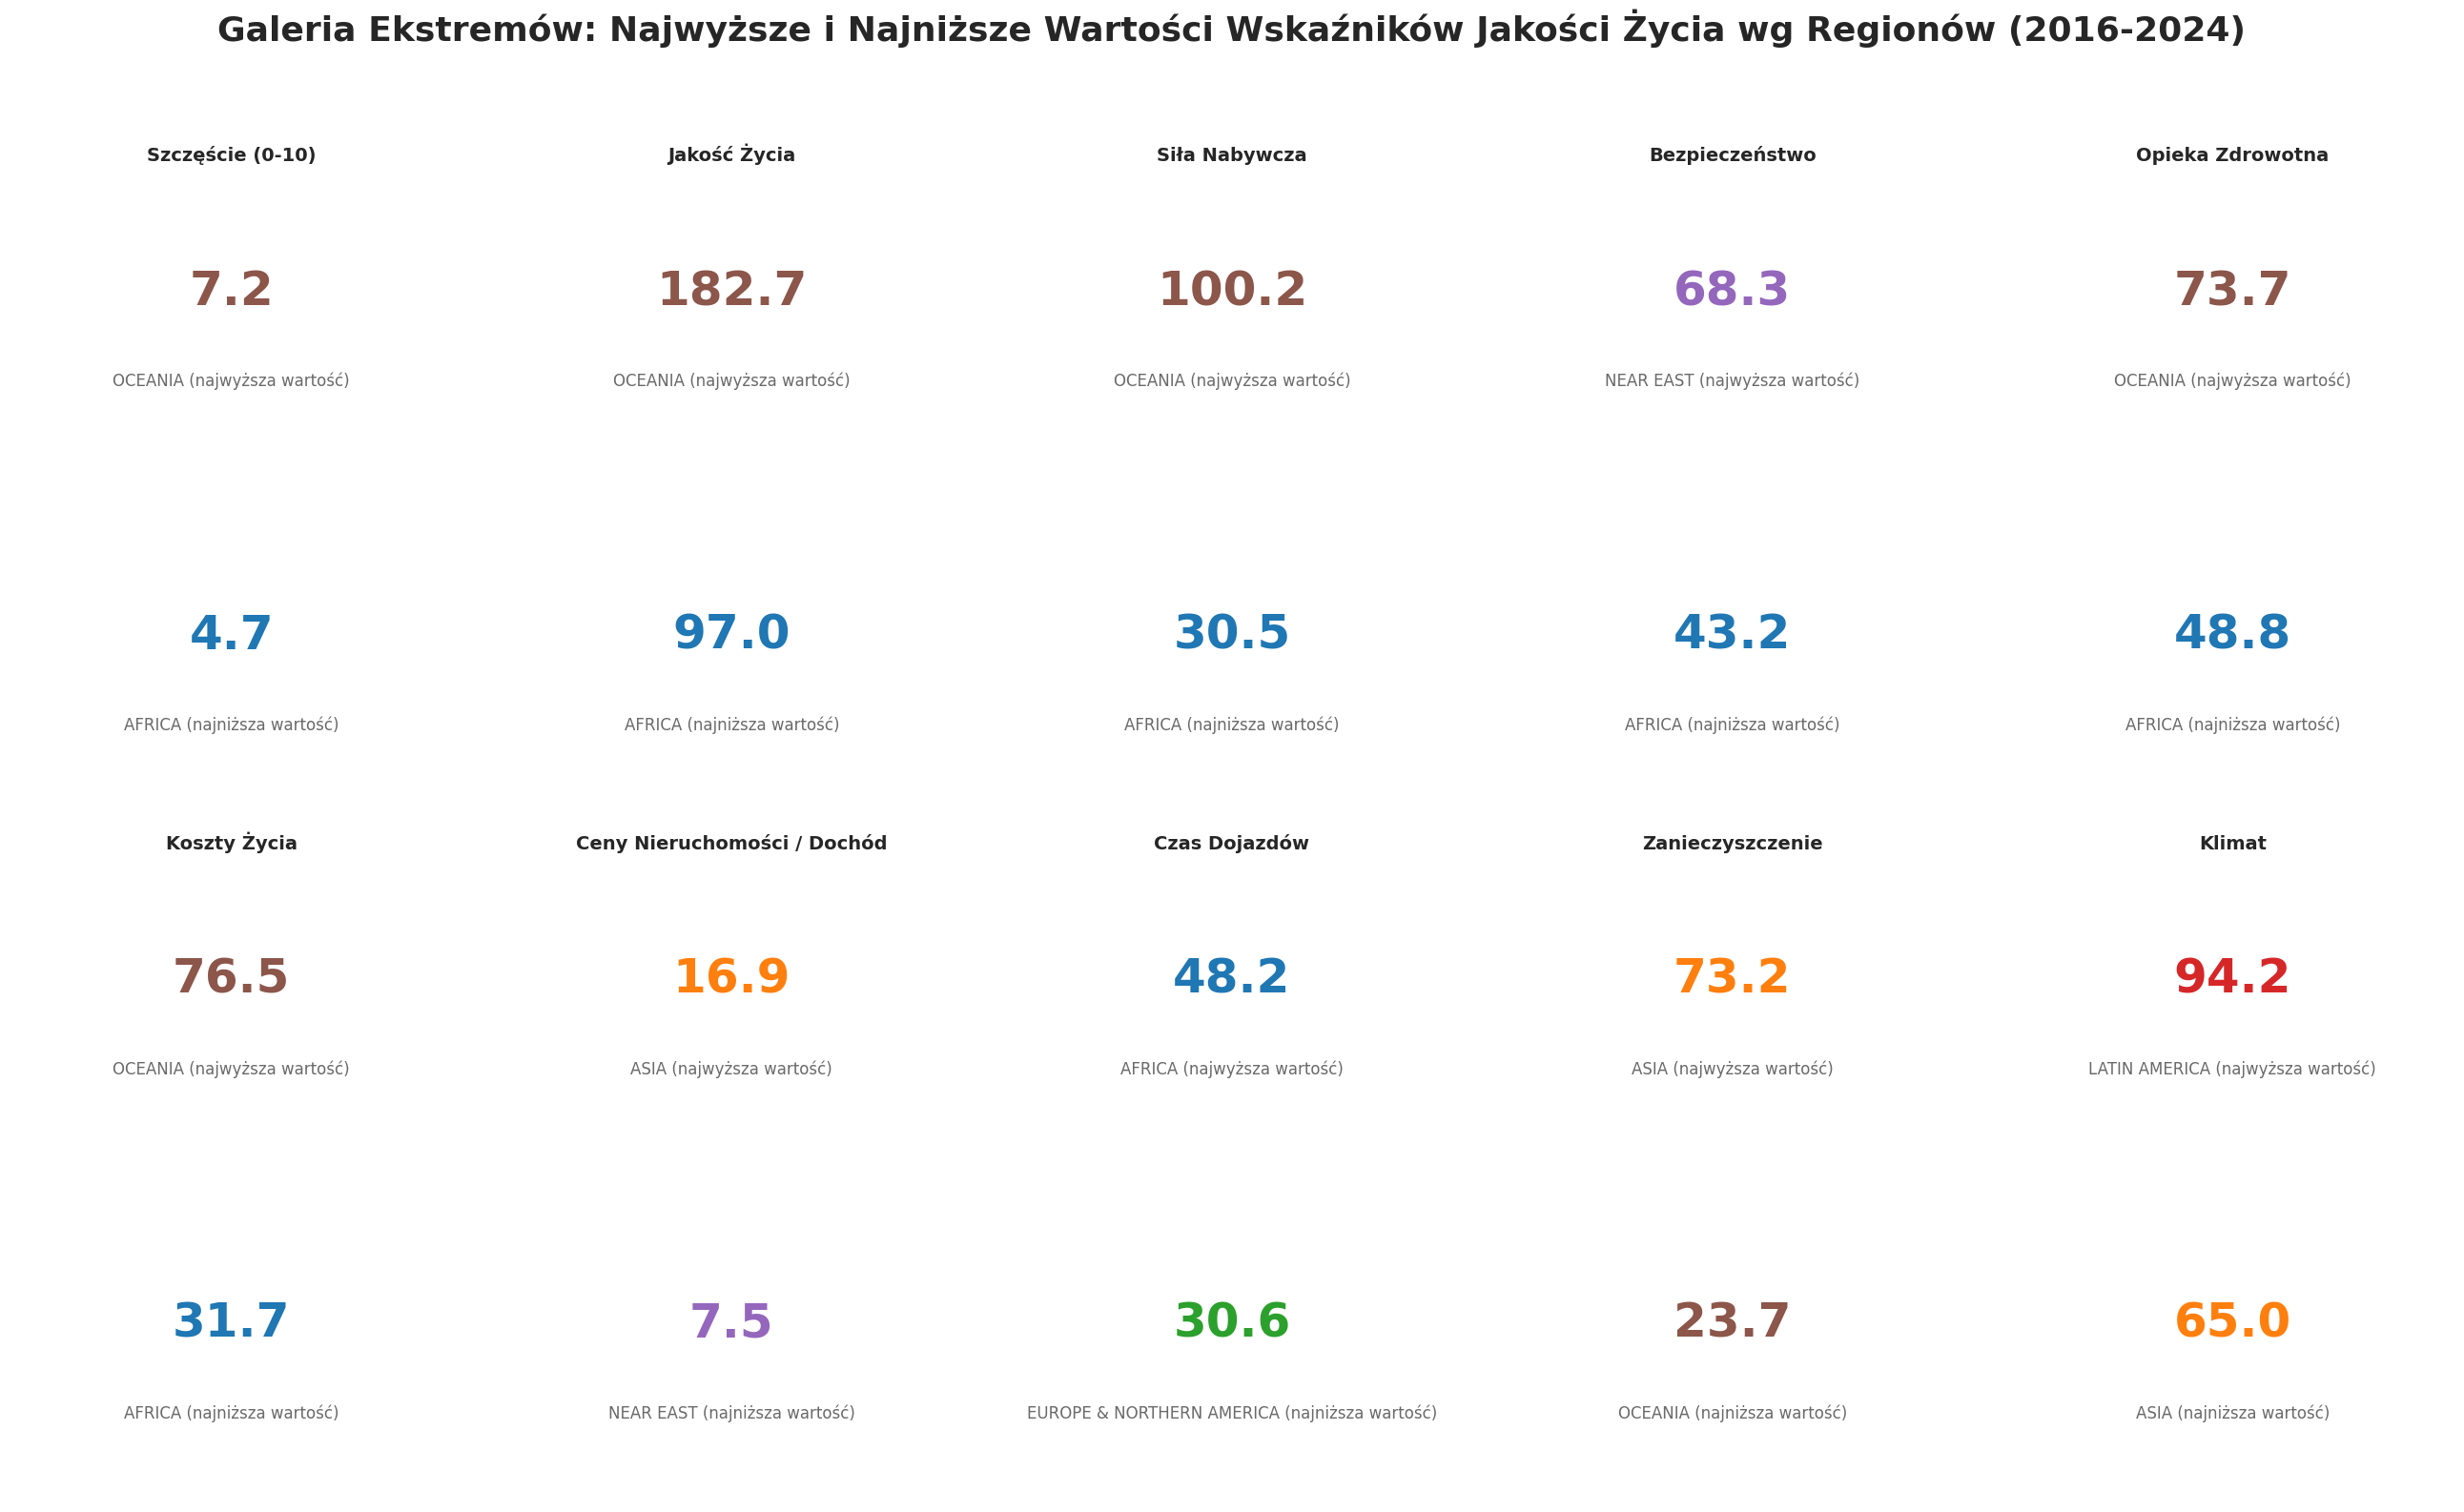

In [17]:
fig, axes = plt.subplots(4, 5, figsize=(26, 16))
for ax in axes.flat:
    ax.axis('off')
metryki = kolumny_num
tytuly = [
    'Szczęście (0-10)', 'Jakość Życia', 'Siła Nabywcza', 'Bezpieczeństwo', 'Opieka Zdrowotna',
    'Koszty Życia', 'Ceny Nieruchomości / Dochód', 'Czas Dojazdów', 'Zanieczyszczenie', 'Klimat'
]

unikalne_regiony = df_region['Region'].unique()
paleta = sns.color_palette("tab10", len(unikalne_regiony))
kolory_regionow = dict(zip(unikalne_regiony, paleta))

for i, metric in enumerate(metryki):
    col = i % 5
    row_top = (i // 5) * 2
    row_bot = row_top + 1

    idx_max = df_region[metric].idxmax()
    val_max = df_region.loc[idx_max, metric]
    reg_max = df_region.loc[idx_max, 'Region']
    kolor_max = kolory_regionow[reg_max]

    idx_min = df_region[metric].idxmin()
    val_min = df_region.loc[idx_min, metric]
    reg_min = df_region.loc[idx_min, 'Region']
    kolor_min = kolory_regionow[reg_min]

    ax_top = axes[row_top, col]
    ax_bot = axes[row_bot, col]

    ax_top.set_title(tytuly[i], fontsize=14, fontweight='bold', ha='center', va='bottom')
    ax_top.text(0.5, 0.6, f"{val_max:.1f}", fontsize=36, fontweight='bold', color=kolor_max, ha='center', va='center', transform=ax_top.transAxes)
    ax_top.text(0.5, 0.3, f"{reg_max} (najwyższa wartość)", fontsize=12, color='dimgray', ha='center', va='center', transform=ax_top.transAxes)

    ax_bot.text(0.5, 0.6, f"{val_min:.1f}", fontsize=36, fontweight='bold', color=kolor_min, ha='center', va='center', transform=ax_bot.transAxes)
    ax_bot.text(0.5, 0.3, f"{reg_min} (najniższa wartość)", fontsize=12, color='dimgray', ha='center', va='center', transform=ax_bot.transAxes)

fig.suptitle("Galeria Ekstremów: Najwyższe i Najniższe Wartości Wskaźników Jakości Życia wg Regionów (2016-2024)", fontsize=26, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## Interpretacja wyników: Pułapka "Maksimum" to nie zawsze "Najlepiej"

---

Patrząc na naszą "Galerię Ekstremów", możemy wyciągnąć bardzo ciekawe wnioski dotyczące jakości życia na świecie. Warto jednak zwrócić szczególną uwagę na to, jak interpretujemy poszczególne wskaźniki!

**1. Oceania – raj na ziemi, ale za najwyższą cenę**
Zgodnie z naszymi danymi, Oceania deklasuje konkurencję w większości pozytywnych kategorii. Ma najwyższy wskaźnik szczęścia (7.2/10), najwyższą ogólną jakość życia (182.7), największą siłę nabywczą obywateli (100.2) oraz najlepszą opiekę zdrowotną (73.7). Ponadto cieszy się najniższym (najlepszym) poziomem zanieczyszczenia środowiska (23.7). Jest jednak jeden haczyk: **Oceania ma również najwyższe koszty życia (76.5)**.

**2. Afryka – region najpoważniejszych wyzwań**
Niestety, Afryka zamyka stawkę w niemal wszystkich kluczowych dla dobrobytu kategoriach. Znajdziemy tam najniższe oceny zadowolenia z życia (4.7/10), najniższą ogólną jakość życia (97.0), najsłabszą siłę nabywczą (30.5) oraz najniższe wskaźniki bezpieczeństwa (43.2) i opieki zdrowotnej (48.8). Mieszkańcy Afryki spędzają również statystycznie najwięcej czasu w uciążliwych dojazdach (najwyższa wartość wskaźnika *Czas Dojazdów* = 48.2). Z drugiej strony, region ten cechuje się bezapelacyjnie najniższymi kosztami życia (31.7).

**3. Zaskoczenia w pozostałych regionach**
* **Azja** zmaga się z ogromnymi wyzwaniami ekologicznymi i rynkowymi – znajdziemy tam najwyższy (najgorszy) wskaźnik zanieczyszczenia środowiska (73.2) oraz najwyższy stosunek cen nieruchomości do dochodów (16.9), co oznacza, że relatywnie najtrudniej tam o własne lokum. Region ten ma również najniżej oceniany klimat (65.0).
* **Ameryka Łacińska (Latin America)** to bezapelacyjny zwycięzca w kategorii najprzyjemniejszego klimatu (94.2).
* **Bliski Wschód (Near East)** może pochwalić się najwyższym poziomem bezpieczeństwa w zestawieniu (68.3) oraz – co ciekawe – najniższym stosunkiem cen nieruchomości do zarobków (7.5), co ułatwia nabycie mieszkania.
* **Europa i Ameryka Północna** dominują tylko w jednej kategorii ekstremów – z racji ugruntowanej infrastruktury mogą pochwalić się najniższym (najlepszym) wskaźnikiem czasu dojazdów do pracy (30.6).

---

**Lekcja Storytellingu:** Nasz wykres pokazuje, jak ważne jest **zrozumienie kontekstu danych**. Matematyczne minimum i maksimum wyciągnięte z kodu Pythona (czyli po prostu to, co wyświetla się na górze i na dole naszej siatki) nie zawsze wprost odzwierciedla to, co "najlepsze" i "najgorsze". W przypadku zanieczyszczeń, kosztów życia, cen mieszkań czy czasu dojazdów – *im mniejsza liczba, tym lepiej!* Jako projektanci komunikatów opartych na danych musimy prowadzić odbiorcę za rękę, aby ułatwić mu odczytanie sensu z tych surowych liczb i uchronić go przed błędnymi wnioskami opartymi jedynie na szybkim rzucie oka na największe wartości.

---

## Zadania dodatkowe dla chętnych

---

W tym zadaniu przełożymy na kod kolejne dwie bardzo ważne koncepcje z książki Cole Nussbaumer Knaflic.

---

#### A. Heatmapa (Tabela Cieplna) dla Jakości Życia na przestrzeni lat

*(Inspiracja: SWD, Rozdział 2 "Choosing an effective visual", str. 42-43 oraz Rozdział 3 "Clutter is your enemy!")*

Cole Knaflic zaznacza, że zwykłe tabele zmuszają nasz system werbalny do pracy – musimy "przeczytać" każdą liczbę, aby ją zinterpretować, co jest procesem powolnym. Wykorzystując formatowanie warunkowe i tworząc tzw. heatmapę, angażujemy znacznie szybszy system wizualny.

Aby w pełni wykorzystać paletę kolorów powiązaną z regionami (którą zdefiniowaliśmy w poprzednim zadaniu), nie użyjemy jednego koloru dla całej tabeli. Zamiast tego nałożymy heatmapę wiersz po wierszu, przypisując każdemu regionowi jego własny gradient!

**Instrukcja krok po kroku:**

1. Przygotuj dane: Stwórz tabelę przestawną (pivot table) ze złączonej ramki `df`. Użyj metody `df.pivot_table(...)`. Jako argument `index` podaj `'Region'`, jako `columns` podaj `'year'`, a do `values` przekaż `'quality_of_life_index'`. Domyślną funkcją agregującą jest średnia, co nam odpowiada. Zapisz wynik do zmiennej `df_pivot_qol`.
2. Zainicjuj wykres: Użyj `fig, ax = plt.subplots(figsize=(30, 8))` do stworzenia bardzo szerokiego płótna, które idealnie wypełni przestrzeń w Colabie.
3. Rysowanie heatmapy (Magia pętli i masek!): Użyj pętli `for region in df_pivot_qol.index:`. Wewnątrz niej:
   * Stwórz maskę ukrywającą wszystkie inne regiony: `maska = pd.DataFrame(True, index=df_pivot_qol.index, columns=df_pivot_qol.columns)`, a następnie odblokuj aktualny region: `maska.loc[region, :] = False`.
   * Stwórz paletę na podstawie słownika z poprzedniego zadania: `cmap = sns.light_palette(kolory_regionow[region], as_cmap=True)`.
   * Narysuj warstwę: `sns.heatmap(df_pivot_qol, mask=maska, cmap=cmap, annot=True, fmt=".1f", linewidths=.5, cbar=False, ax=ax)`. Użycie `cbar=False` jest kluczowe, aby zapobiec nakładaniu się wielu legend.
4. Oczyść wykres (Decluttering): Tytuły osi są oczywiste z samego kontekstu (lata i regiony). Usuń je ustawiając puste stringi: `ax.set_xlabel("")` oraz `ax.set_ylabel("")`.
5. Nadaj tytuł: Użyj `ax.set_title(...)` wpisując tytuł, dodając pogrubienie `fontweight='bold'` oraz ustawiając wielkość `fontsize=20`. Odsuń nieco tytuł od wykresu za pomocą parametru `pad=20`.

---

#### B. Wykres Punktowy z kwadrantami (Wizualna Hierarchia i Hiszpania jako lider)

*(Inspiracja: SWD, Rozdział 5 "Think like a designer", str. 152-153 oraz Rozdział 7 "Lessons in storytelling")*

Cole pokazuje, że dodanie linii średnich do wykresu punktowego dzieli go na cztery kwadranty (super-kategorie), co ogromnie ułatwia interpretację. Spychamy większość danych do szarego tła, a za pomocą mocnego koloru wyciągamy na pierwszy plan tę jedną historię, którą chcemy opowiedzieć.

Zestawimy Koszty Życia z Siłą Nabywczą dla Europy i Ameryki Północnej w ostatnim dostępnym roku. Jak się za chwilę przekonasz, **tylko Hiszpania (Spain)** znajdzie się w "złotym kwadrancie" (niskie koszty życia, wysoka siła nabywcza) i to właśnie ona będzie głównym bohaterem naszej opowieści!

**Instrukcja krok po kroku:**

1. Przygotuj dane: Utwórz zmienną `ostatni_rok = df['year'].max()`. Zbuduj nową ramkę `df_eur`, filtrując z ramki `df` tylko wiersze, gdzie `'year' == ostatni_rok` oraz `'Region' == 'EUROPE & NORTHERN AMERICA'`. Wylicz z niej wartości średnie: `avg_cost = df_eur['cost_of_living_index'].mean()` oraz `avg_power = df_eur['purchasing_power_index'].mean()`.
2. Zainicjuj wykres: Wywołaj `fig, ax = plt.subplots(figsize=(30, 8))` (ponownie korzystamy z pełnej szerokości notatnika).
3. Linie odniesienia (Kwadranty): Użyj funkcji do rysowania linii na całych osiach. Dla średnich kosztów życia: `ax.axvline(x=avg_cost, color='darkgrey', linestyle='--')`. Dla średniej siły nabywczej: `ax.axhline(y=avg_power, color='darkgrey', linestyle='--')`.
4. Rysowanie tła: Skonstruuj wykres punktowy dla wszystkich państw regionu. Użyj `sns.scatterplot()`, podając `data=df_eur`, `x='cost_of_living_index'`, `y='purchasing_power_index'`, `color='lightgrey'`, `s=80` (wielkość punktu) oraz przypisując do osi `ax=ax`.
5. Wyróżnienie "Złotego Kwadrantu" (Hiszpanii): Przefiltrujmy dane, aby znaleźć kraje z siłą nabywczą powyżej średniej i kosztami życia poniżej średniej: `df_gold = df_eur[(df_eur['cost_of_living_index'] < avg_cost) & (df_eur['purchasing_power_index'] > avg_power)]`. Znajduje się tam tylko Hiszpania! Narysuj ją na wierzchu: `sns.scatterplot()`, z `data=df_gold`, mocnym kolorem `color='dodgerblue'` i rozmiarem `s=150`.
6. Oczyszczanie (Decluttering): Usuń górną i prawą ramkę używając `ax.spines['top'].set_visible(False)` i `ax.spines['right'].set_visible(False)`. Ustaw nazwy osi za pomocą `ax.set_xlabel('Koszty Życia', fontsize=14)` oraz `ax.set_ylabel('Siła Nabywcza', fontsize=14)`.
7. Bezpośrednie etykietowanie: Podpiszemy tylko naszego lidera. Użyj pętli `for idx, row in df_gold.iterrows():` i dodaj tekst: `ax.text(row['cost_of_living_index'] + 1.0, row['purchasing_power_index'], row['country'], color='dimgray', fontsize=14, va='center')`.
8. Tytuł: Nasz tytuł nie może być nudnym opisem osi. Skoro odkryliśmy, że Hiszpania króluje, użyjmy jej w tytule! `ax.set_title("Hiszpania jako jedyna w Europie oferuje wysoką siłę nabywczą przy kosztach życia poniżej średniej", fontsize=20, fontweight='bold', loc='left', pad=20)`. Na koniec wywołaj `plt.tight_layout()` oraz `plt.show()`.

---

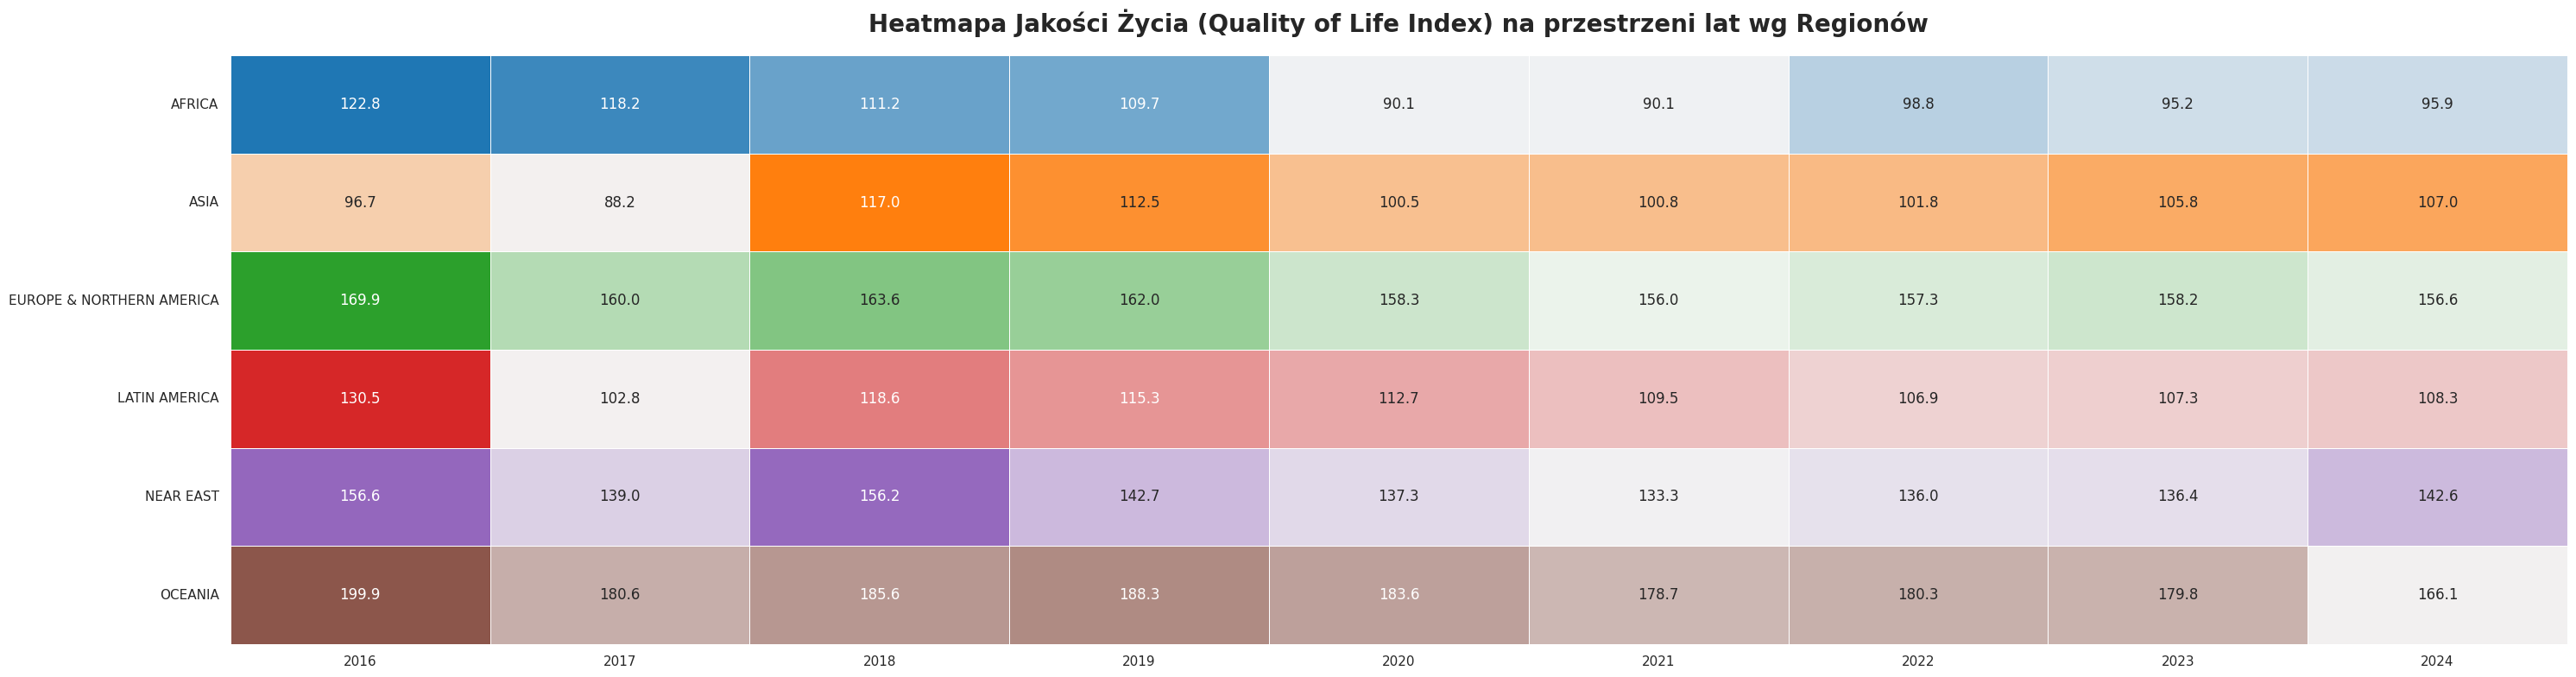

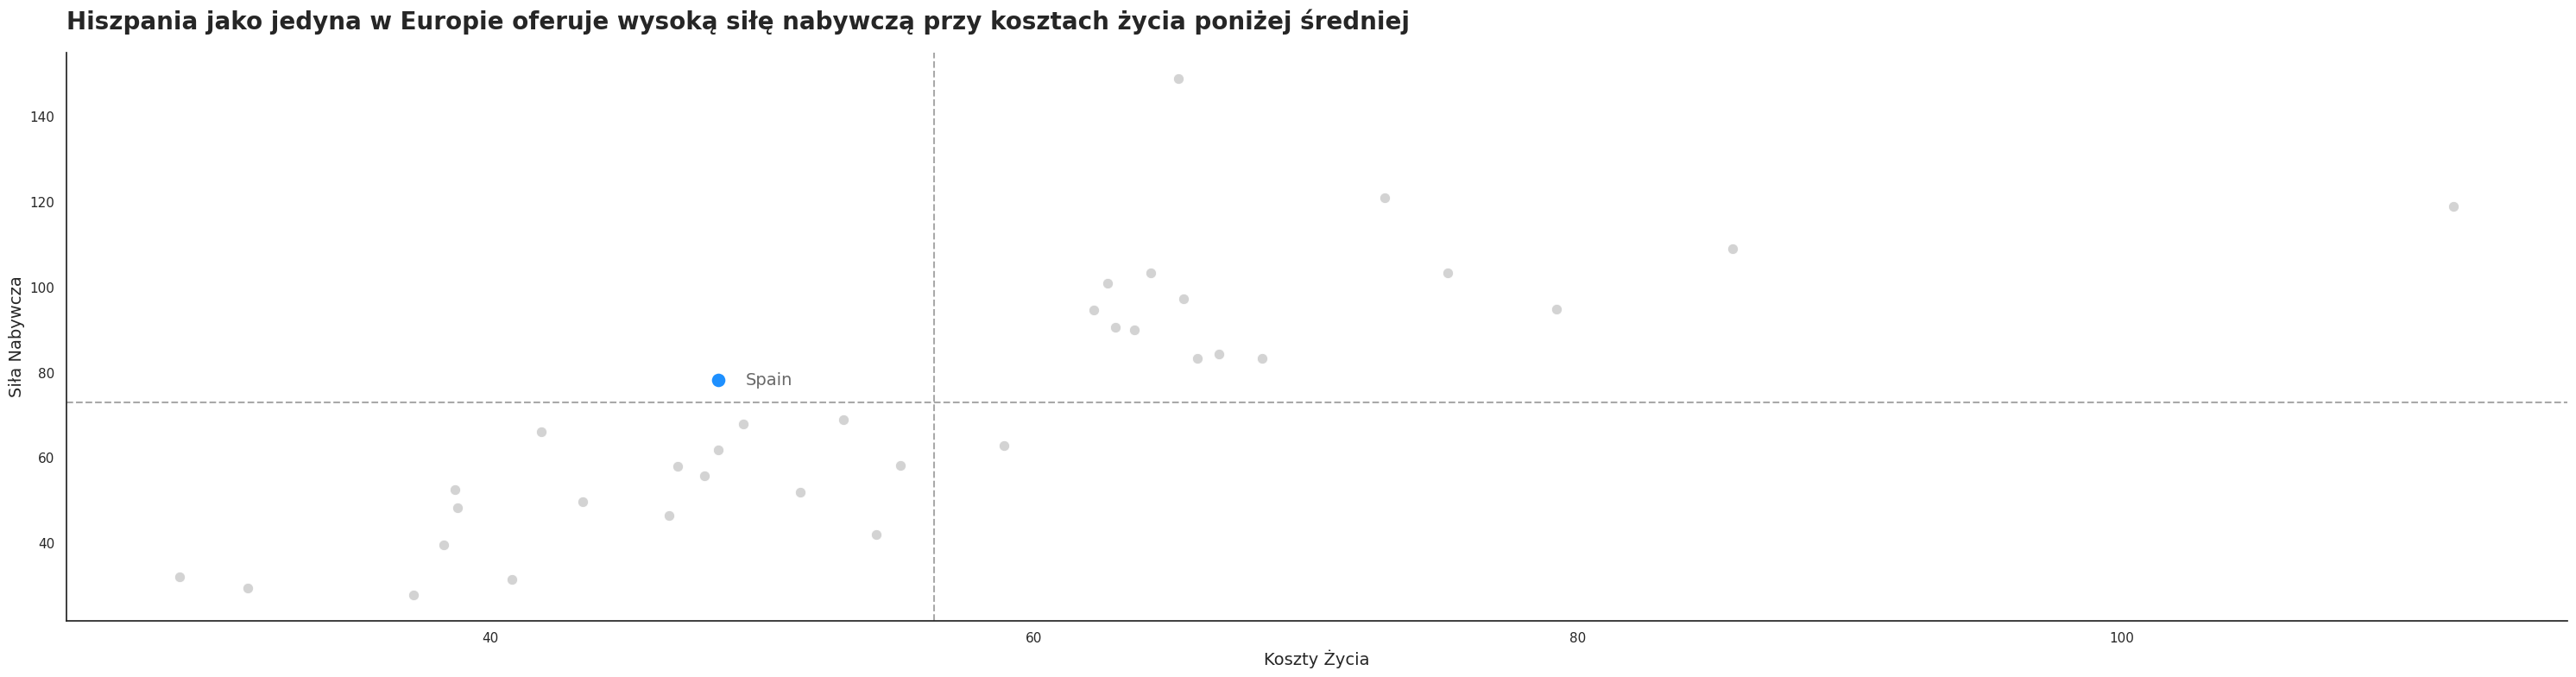

In [18]:
df_pivot_qol = df.pivot_table(index='Region', columns='year', values='quality_of_life_index')
fig, ax = plt.subplots(figsize=(30, 8))

for region in df_pivot_qol.index:
    maska = pd.DataFrame(True, index=df_pivot_qol.index, columns=df_pivot_qol.columns)
    maska.loc[region, :] = False
    cmap = sns.light_palette(kolory_regionow[region], as_cmap=True)
    sns.heatmap(df_pivot_qol, mask=maska, cmap=cmap, annot=True, fmt=".1f", linewidths=.5, cbar=False, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title("Heatmapa Jakości Życia (Quality of Life Index) na przestrzeni lat wg Regionów", fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()



ostatni_rok = df['year'].max()
df_eur = df[(df['year'] == ostatni_rok) & (df['Region'] == 'EUROPE & NORTHERN AMERICA')]
avg_cost = df_eur['cost_of_living_index'].mean()
avg_power = df_eur['purchasing_power_index'].mean()

fig, ax = plt.subplots(figsize=(30, 8))

ax.axvline(x=avg_cost, color='darkgrey', linestyle='--')
ax.axhline(y=avg_power, color='darkgrey', linestyle='--')

sns.scatterplot(data=df_eur, x='cost_of_living_index', y='purchasing_power_index', color='lightgrey', s=80, ax=ax)

df_gold = df_eur[(df_eur['cost_of_living_index'] < avg_cost) & (df_eur['purchasing_power_index'] > avg_power)]
sns.scatterplot(data=df_gold, x='cost_of_living_index', y='purchasing_power_index', color='dodgerblue', s=150, ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Koszty Życia', fontsize=14)
ax.set_ylabel('Siła Nabywcza', fontsize=14)

for idx, row in df_gold.iterrows():
    ax.text(row['cost_of_living_index'] + 1.0, row['purchasing_power_index'], row['country'], color='dimgray', fontsize=14, va='center')

ax.set_title("Hiszpania jako jedyna w Europie oferuje wysoką siłę nabywczą przy kosztach życia poniżej średniej", fontsize=20, fontweight='bold', loc='left', pad=20)

plt.tight_layout()
plt.show()